# Loan Default Probability 

# 1. XÁC ĐỊNH BÀI TOÁN

Xử lý các dữ liệu missing, encoding, loại biến không logic, target default, correlation filter trong giai đoạn từ năm 2007 đến quý III năm 2017 của Lending Club.

Bộ dữ liệu này chứa hơn 887 nghìn quan sát và 150 biến, trong đó có một biến mô tả trạng thái của khoản vay.

# 2. DOWNLOAD PACKAGE VÀ DATASET

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

from pickle import dump
from pickle import load

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
loans = pd.read_csv('loan_dataset.csv.zip', compression='zip',encoding='utf-8')

In [4]:
dataset = loans

In [5]:
type(dataset)

pandas.core.frame.DataFrame

# 3. TIỀN XỬ LÝ DỮ LIỆU

## 3.1. CHUẨN BỊ BIẾN ĐẦU VÀO


In [6]:
dataset['loan_status'].value_counts(dropna=False)

loan_status
Current                                                788950
Fully Paid                                             646902
Charged Off                                            168084
Late (31-120 days)                                      23763
In Grace Period                                         10474
Late (16-30 days)                                        5786
Does not meet the credit policy. Status:Fully Paid       1988
Does not meet the credit policy. Status:Charged Off       761
Default                                                    70
NaN                                                        23
Name: count, dtype: int64

Trong đồ án này, nhóm chỉ thực hiện việc tìm hiểu sự khác biệt về các đặc điểm giữa các khoản vay đã hoàn tất, đã được thanh toán đầy đủ hoặc đã bị xóa. Và không xem xét các khoản vay đang trong tình trạng hiện hành, không đáp ứng chính sách tín dụng, bị vỡ nợ hoặc có trạng thái không xác định. Chốt lại, nhóm chỉ giữ lại các khoản vay có trạng thái "Đã thanh toán đầy đủ" hoặc "Đã xóa".

In [7]:
dataset = dataset.loc[dataset['loan_status'].isin(['Fully Paid', 'Charged Off'])]

dataset['loan_status'].value_counts(dropna=False)

dataset['loan_status'].value_counts(normalize=True, dropna=False)

loan_status
Fully Paid     0.793758
Charged Off    0.206242
Name: proportion, dtype: float64

Khoảng 79% số khoản vay còn lại đã được thanh toán đầy đủ và 21% đã bị xóa sổ, hiện tại nhóm đang gặp phải vấn đề phân loại mất cân bằng.

In [8]:
dataset['charged_off'] = (dataset['loan_status'] == 'Charged Off').apply(np.uint8)
dataset.drop('loan_status', axis=1, inplace=True)

## 3.2. PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU

Tập dữ liệu đầy đủ có 150 đặc trưng cho mỗi khoản vay.
Nhóm thực hiện loại bỏ các đặc trưng trong các bước sau bằng các phương pháp khác nhau:
* Loại bỏ các đặc trưng có hơn 80% giá trị bị thiếu

* Loại bỏ các đặc trưng không có ý nghĩa dự báo lúc xét duyệt vay

* Loại bỏ các đặc trưng có tương quan thấp (< 0.03) với biến dự đoán

### 3.2.1. Loại bỏ các đặc trưng có hơn 80% giá trị bị thiếu

Đầu tiên, tính toán tỷ lệ dữ liệu thiếu cho từng đặc trưng:

In [9]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

missing_fractions.head(10)

member_id                                     1.000000
next_pymnt_d                                  1.000000
orig_projected_additional_accrued_interest    0.999876
sec_app_mths_since_last_major_derog           0.999628
hardship_length                               0.999275
deferral_term                                 0.999275
hardship_end_date                             0.999275
hardship_reason                               0.999275
hardship_start_date                           0.999275
hardship_type                                 0.999275
dtype: float64

In [10]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(drop_list)

['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_ma

In [11]:
len(drop_list)

58

In [12]:
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(814986, 92)

### 3.2.2. Loại bỏ các đặc trưng không có ý nghĩa dự báo lúc xét duyệt vay

Để lọc thêm các đặc trưng, nhóm kiểm tra qua mô tả trong dữ liệu và giữ lại các đặc trưng mà nhóm cho là không có ý nghĩa dự báo lúc xét duyệt vay.

Dưới đây là quy trình mã hoá và xoá bỏ các dữ liệu không cần thiết

In [13]:
print(sorted(dataset.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'charged_off', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sa

Danh sách các đặc trưng được lưu giữ:

In [14]:
keep_list = ['charged_off','funded_amnt','addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code','last_pymnt_amnt','num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',"bc_util","bc_open_to_buy","avg_cur_bal","acc_open_past_24mths" ]

len(keep_list)

40

In [15]:
drop_list = [col for col in dataset.columns if col not in keep_list]

dataset.drop(labels=drop_list, axis=1, inplace=True)

dataset.shape

(814986, 39)

### 3.2.3. Loại bỏ các đặc trưng có tương quan thấp (< 0.03) với biến dự đoán

In [16]:
dataset.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,open_acc,pub_rec,...,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,pub_rec_bankruptcies,charged_off
count,814986.000000,814986.000000,814986.000000,814986.000000,8.149860e+05,814950.000000,814986.000000,814986.000000,814986.000000,814986.000000,...,767705.000000,747447.000000,759810.00000,759321.000000,747458.000000,747458.000000,767705.000000,747459.000000,814289.000000,814986.000000
mean,14315.458210,14301.566929,13.490993,436.749624,7.523039e+04,17.867719,695.603151,699.603264,11.521099,0.205734,...,4.716176,13519.786576,9464.94483,61.575664,180.843182,12.705577,1.758707,5.658872,0.132007,0.206242
std,8499.799241,8492.964986,4.618486,255.732093,6.524373e+04,8.856477,31.352251,31.352791,5.325064,0.584933,...,3.152369,16221.882463,14575.87033,27.871170,92.192939,15.654277,2.081730,3.215863,0.375188,0.404606
min,500.000000,500.000000,5.320000,4.930000,0.000000e+00,-1.000000,625.000000,629.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8000.000000,8000.000000,9.990000,251.400000,4.500000e+04,11.640000,670.000000,674.000000,8.000000,0.000000,...,2.000000,3119.000000,1312.00000,40.800000,117.000000,4.000000,0.000000,3.000000,0.000000,0.000000
50%,12000.000000,12000.000000,13.110000,377.040000,6.500000e+04,17.360000,690.000000,694.000000,11.000000,0.000000,...,4.000000,7508.000000,4261.00000,65.400000,164.000000,8.000000,1.000000,5.000000,0.000000,0.000000
75%,20000.000000,20000.000000,16.290000,576.290000,9.000000e+04,23.630000,710.000000,714.000000,14.000000,0.000000,...,6.000000,18827.000000,11343.00000,86.000000,228.000000,15.000000,3.000000,7.000000,0.000000,0.000000
max,40000.000000,40000.000000,30.990000,1714.540000,9.550000e+06,999.000000,845.000000,850.000000,90.000000,86.000000,...,56.000000,958084.000000,559912.00000,339.600000,842.000000,372.000000,51.000000,57.000000,12.000000,1.000000


#### PHÂN TÍCH CÁC BIẾN ĐẶC TRƯNG RỜI RẠC

In [17]:
dataset[['id','emp_title','title','zip_code']].describe()

,id,emp_title,title,zip_code
count,814986,766415,807067,814986
unique,814986,280473,60297,925
top,66601274,Teacher,Debt consolidation,945xx
freq,1,11351,371874,9517


In [18]:
dataset.drop(['id','emp_title','title','zip_code'], axis=1, inplace=True)

In [19]:
dataset['term'] = dataset['term'].apply(lambda s: np.int8(s.split()[0]))

In [20]:
dataset.groupby('term')['charged_off'].value_counts(normalize=True).loc[:,1]

term
36    0.165710
60    0.333793
Name: proportion, dtype: float64

Các khoản vay có thời hạn 5 năm có khả năng bị xóa nợ cao gấp hơn hai lần so với các khoản vay có thời hạn 3 năm.

In [22]:
dataset['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)

dataset['emp_length'].replace('< 1 year', '0 years', inplace=True)

def emp_length_to_int(s):
    if pd.isnull(s):
        return s
    else:
        return np.int8(s.split()[0])
    
dataset['emp_length'] = dataset['emp_length'].apply(emp_length_to_int)

<Axes: xlabel='emp_length'>

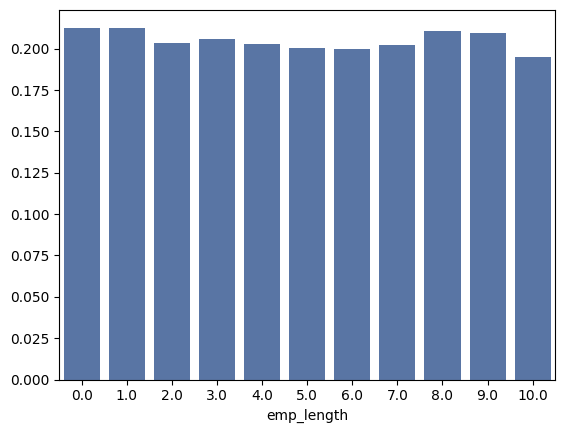

In [23]:
charge_off_rates = dataset.groupby('emp_length')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)

Tình trạng khoản vay dường như không thay đổi nhiều theo thời gian làm việc trung bình, do đó đặc trưng này bị loại bỏ.

In [24]:
dataset.drop(['emp_length'], axis=1, inplace=True)

<Axes: xlabel='sub_grade'>

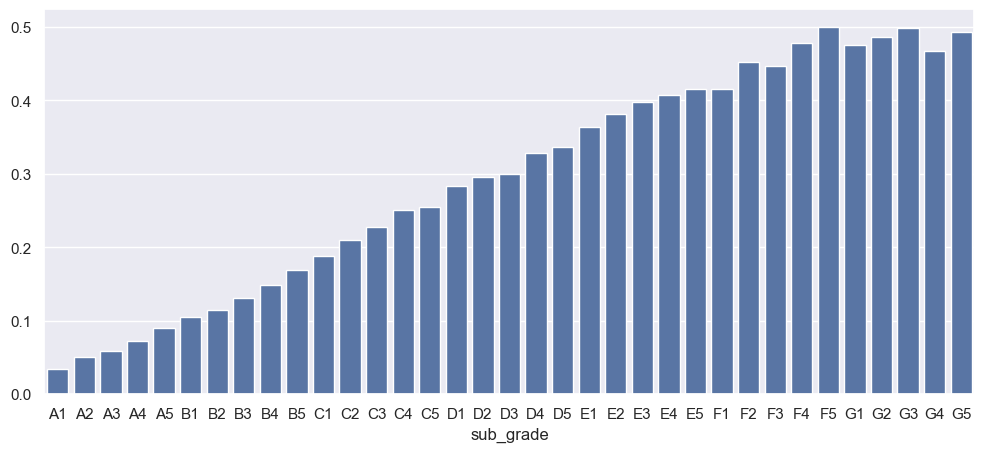

In [25]:
charge_off_rates = dataset.groupby('sub_grade')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.set(rc={'figure.figsize':(12,5)})
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)

Có một xu hướng rõ rệt cho thấy xác suất khoản vay bị ghi nhận là nợ xấu tăng lên khi mức subgrade trở nên thấp hơn.

In [27]:
dataset['earliest_cr_line'] = dataset['earliest_cr_line'].apply(lambda s: int(s[-4:]))

#### PHÂN TÍCH BIẾN ĐẶC TRƯNG LIÊN TỤC

In [28]:
dataset[['annual_inc']].describe()

,annual_inc
count,8.149860e+05
mean,7.523039e+04
std,6.524373e+04
min,0.000000e+00
25%,4.500000e+04
50%,6.500000e+04
75%,9.000000e+04
max,9.550000e+06


Thu nhập hàng năm dao động từ 0 đến 9.550.000 đô la, với giá trị trung vị là 65.000 đô la. Do phạm vi thu nhập rộng, nhóm thực hiện phép biến đổi logarit cho biến thu nhập hàng năm.

In [29]:
dataset['log_annual_inc'] = dataset['annual_inc'].apply(lambda x: np.log10(x+1))
dataset.drop('annual_inc', axis=1, inplace=True)

In [30]:
dataset[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


Vì hệ số tương quan giữa điểm FICO thấp và cao là 1, nên tốt hơn hết là chỉ giữ lại một đặc điểm duy nhất, đó là điểm FICO trung bình.

In [31]:
dataset['fico_score'] = 0.5*dataset['fico_range_low'] + 0.5*dataset['fico_range_high']

dataset.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

In [32]:
dataset['charged_off'].value_counts()

charged_off
0    646902
1    168084
Name: count, dtype: int64

#### LOẠI BỎ CÁC GIÁ TRỊ TƯƠNG QUAN <0.03

In [33]:
from sklearn.preprocessing import LabelEncoder

In [34]:
categorical_feature_mask = dataset.dtypes==object
categorical_cols = dataset.columns[categorical_feature_mask].tolist()

In [35]:
categorical_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [36]:
le = LabelEncoder()
dataset[categorical_cols] = dataset[categorical_cols].apply(lambda col: le.fit_transform(col))
dataset[categorical_cols].head(10)

,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,2,10,5,1,2,45,1,0
1,0,2,1,0,1,4,1,0
2,3,15,5,1,1,24,1,0
4,2,12,5,1,2,3,0,0
5,2,12,5,1,2,31,0,0
6,1,9,1,1,4,23,0,0
7,1,8,4,2,2,45,1,0
8,2,13,5,1,1,47,0,0
9,1,8,5,0,2,20,0,0
10,1,9,5,2,2,22,0,0


In [40]:
correlation = dataset.corr()
correlation_chargeOff = abs(correlation['charged_off'])

In [41]:
correlation_chargeOff.sort_values(ascending=False)

charged_off              1.000000
last_pymnt_amnt          0.381359
sub_grade                0.266394
grade                    0.260958
int_rate                 0.247815
term                     0.177708
fico_score               0.139429
dti                      0.123031
acc_open_past_24mths     0.098985
verification_status      0.087380
bc_open_to_buy           0.086896
avg_cur_bal              0.085777
num_actv_rev_tl          0.077211
bc_util                  0.077132
mort_acc                 0.077086
log_annual_inc           0.074216
revol_util               0.072185
home_ownership           0.071900
funded_amnt              0.064258
loan_amnt                0.064139
mo_sin_rcnt_rev_tl_op    0.053469
mo_sin_old_rev_tl_op     0.048529
installment              0.046291
earliest_cr_line         0.042395
open_acc                 0.034652
pub_rec                  0.023105
purpose                  0.017887
pub_rec_bankruptcies     0.017314
initial_list_status      0.016873
revol_bal     

In [42]:
drop_list_corr = sorted(list(correlation_chargeOff[correlation_chargeOff < 0.03].index))
print(drop_list_corr)

['addr_state', 'application_type', 'initial_list_status', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'total_acc']


In [43]:
drop_list_corr = ['pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'total_acc']

In [44]:
dataset.drop(labels=drop_list_corr, axis=1, inplace=True)
dataset.shape

(814986, 29)

In [45]:
dataset.head(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,15000.0,15000.0,60,12.39,336.64,2,10,5,1,2,...,29828.0,9525.0,4.7,244.0,1.0,0.0,4.0,0,4.892100,752.0
1,10400.0,10400.0,36,6.99,321.08,0,2,1,0,1,...,9536.0,7599.0,41.5,290.0,1.0,1.0,9.0,1,4.763435,712.0
2,21425.0,21425.0,60,15.59,516.36,3,15,5,1,1,...,4232.0,324.0,97.8,136.0,7.0,0.0,4.0,0,4.804827,687.0
4,7650.0,7650.0,36,13.66,260.20,2,12,5,1,2,...,5857.0,332.0,93.2,148.0,8.0,0.0,4.0,1,4.698979,687.0
5,9600.0,9600.0,36,13.66,326.53,2,12,5,1,2,...,3214.0,6494.0,69.2,265.0,23.0,0.0,7.0,0,4.838855,682.0


## 3.3. LẤY MẪU DỮ LIỆU

In [46]:
loanstatus_0 = dataset[dataset["charged_off"]==0]
loanstatus_1 = dataset[dataset["charged_off"]==1]
subset_of_loanstatus_0 = loanstatus_0.sample(n=5500)
subset_of_loanstatus_1 = loanstatus_1.sample(n=5500)
dataset = pd.concat([subset_of_loanstatus_1, subset_of_loanstatus_0])
dataset = dataset.sample(frac=1).reset_index(drop=True)
print("Current shape of dataset :",dataset.shape)
dataset.head()

Current shape of dataset : (11000, 29)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,25000.0,25000.0,36,16.32,882.89,4,21,1,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4.929424,687.0
1,7200.0,7200.0,36,12.99,242.57,2,10,5,0,2,...,1274.0,233.0,88.3,77.0,22.0,0.0,5.0,1,4.619104,692.0
2,3200.0,3200.0,36,13.98,109.34,2,12,5,0,2,...,3640.0,174.0,65.2,86.0,1.0,0.0,3.0,1,4.579795,682.0
3,6000.0,6000.0,36,6.03,182.62,0,0,1,0,6,...,NaN,105064.0,5.9,NaN,NaN,5.0,NaN,0,4.954247,792.0
4,31500.0,31500.0,60,13.98,732.63,2,12,1,1,2,...,13169.0,3054.0,86.8,112.0,8.0,1.0,8.0,1,4.977728,672.0


In [47]:
dataset.fillna(dataset.mean(),inplace = True)